<a href="https://colab.research.google.com/github/JonathasHFerreira/Deteccao_de_fraudes_jonathas/blob/main/Risco_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
# The previous attempt with 'diabetes_prediction_dataset.csv' failed.
# Let's list the files in the dataset to find the correct one.
!ls /kaggle/input/diabetes-risk-prediction

# Once you identify the correct filename from the output above, update 'file_path' here.
file_path = "diabetes_risk.csv" # Updated with the correct filename found above

# Load the latest version
# This line is commented out for now. Uncomment it after updating 'file_path' with the correct filename.
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mansiaggarwal88/diabetes-risk-prediction",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

ls: cannot access '/kaggle/input/diabetes-risk-prediction': No such file or directory


/tmp/ipykernel_2396/1064370516.py:16: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'diabetes-risk-prediction' dataset.
First 5 records:    patient_id  age  gender       city   bmi family_history_diabetes  \
0           1   47  Female     Mumbai  26.5                     Yes   
1           2   53  Female     Mumbai  20.5                     Yes   
2           3   47    Male      Thane  31.3                      No   
3           4   41    Male  Bengaluru  22.8                      No   
4           5   57  Female  Bengaluru  16.7                      No   

  physical_activity_level       diet_type smoking_status alcohol_consumption  \
0               Sedentary      Vegetarian          Never               Never   
1                Moderate      Vegetarian          Never               Never   
2                Moderate  Non-Vegetarian        Current             Regular   
3               Sedentary  Non-Vegetarian          Never               Never   
4               Sedentary  Non-Vegetarian        Current          Occasional 

In [2]:
import numpy as np # linear algebra
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

RISK_ORDER = ["Low", "Moderate", "High"]
RISK_COLORS = {"Low": "#4C9A6B", "Moderate": "#E8A33D", "High": "#C64B4B"}

In [3]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 15,000 rows x 19 columns


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

In [5]:
df.describe(include="all")

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
count,15000.000000,15000.000000,15000,15000,15000.000000,15000,15000,15000,14528,11212,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14537,15000
unique,NaN,NaN,3,18,NaN,2,3,4,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3
top,NaN,NaN,Male,Mumbai,NaN,No,Active,Non-Vegetarian,Never,Never,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Middle,Low
freq,NaN,NaN,7664,2243,NaN,9756,5100,8195,10119,5616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7305,9000
mean,7500.500000,44.333667,NaN,NaN,23.062260,NaN,NaN,NaN,NaN,NaN,7.309860,5.941200,168.789933,6.878387,139.496200,86.256933,100.207933,NaN,NaN
std,4330.271354,10.383753,NaN,NaN,4.046391,NaN,NaN,NaN,NaN,NaN,1.109372,2.148406,38.365822,0.843276,12.660785,8.386529,10.760331,NaN,NaN
min,1.000000,18.000000,NaN,NaN,15.000000,NaN,NaN,NaN,NaN,NaN,3.000000,1.000000,72.000000,4.800000,80.000000,50.000000,73.200000,NaN,NaN
25%,3750.750000,38.000000,NaN,NaN,20.100000,NaN,NaN,NaN,NaN,NaN,6.700000,4.000000,145.000000,6.300000,130.000000,80.000000,92.500000,NaN,NaN
50%,7500.500000,45.000000,NaN,NaN,22.700000,NaN,NaN,NaN,NaN,NaN,7.000000,6.000000,165.000000,6.800000,140.000000,88.000000,99.300000,NaN,NaN
75%,11250.250000,52.000000,NaN,NaN,25.600000,NaN,NaN,NaN,NaN,NaN,8.000000,7.000000,189.000000,7.300000,150.000000,90.000000,106.900000,NaN,NaN


In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
alcohol_consumption,3788,25.25
smoking_status,472,3.15
income_bracket,463,3.09


In [7]:
df["smoking_status"] = df["smoking_status"].fillna("Unknown")
df["alcohol_consumption"] = df["alcohol_consumption"].fillna("Unknown")
df["income_bracket"] = df["income_bracket"].fillna(df["income_bracket"].mode()[0])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            15000 non-null  object 
 9   alcohol_consumption       15000 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

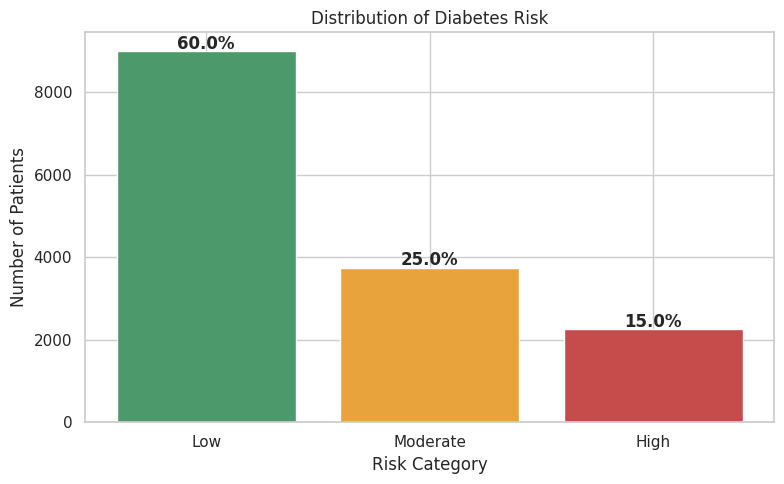

,count
diabetes_risk,
Low,9000
Moderate,3750
High,2250


In [9]:
risk_counts = df["diabetes_risk"].value_counts().reindex(RISK_ORDER)
risk_pct = (risk_counts / len(df) * 100).round(1)

fig, ax = plt.subplots()
bars = ax.bar(risk_counts.index, risk_counts.values,
              color=[RISK_COLORS[r] for r in RISK_ORDER])
for bar, pct in zip(bars, risk_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{pct}%", ha="center", fontweight="bold")
ax.set_title("Distribution of Diabetes Risk")
ax.set_ylabel("Number of Patients")
ax.set_xlabel("Risk Category")
plt.tight_layout()
plt.show()

risk_counts

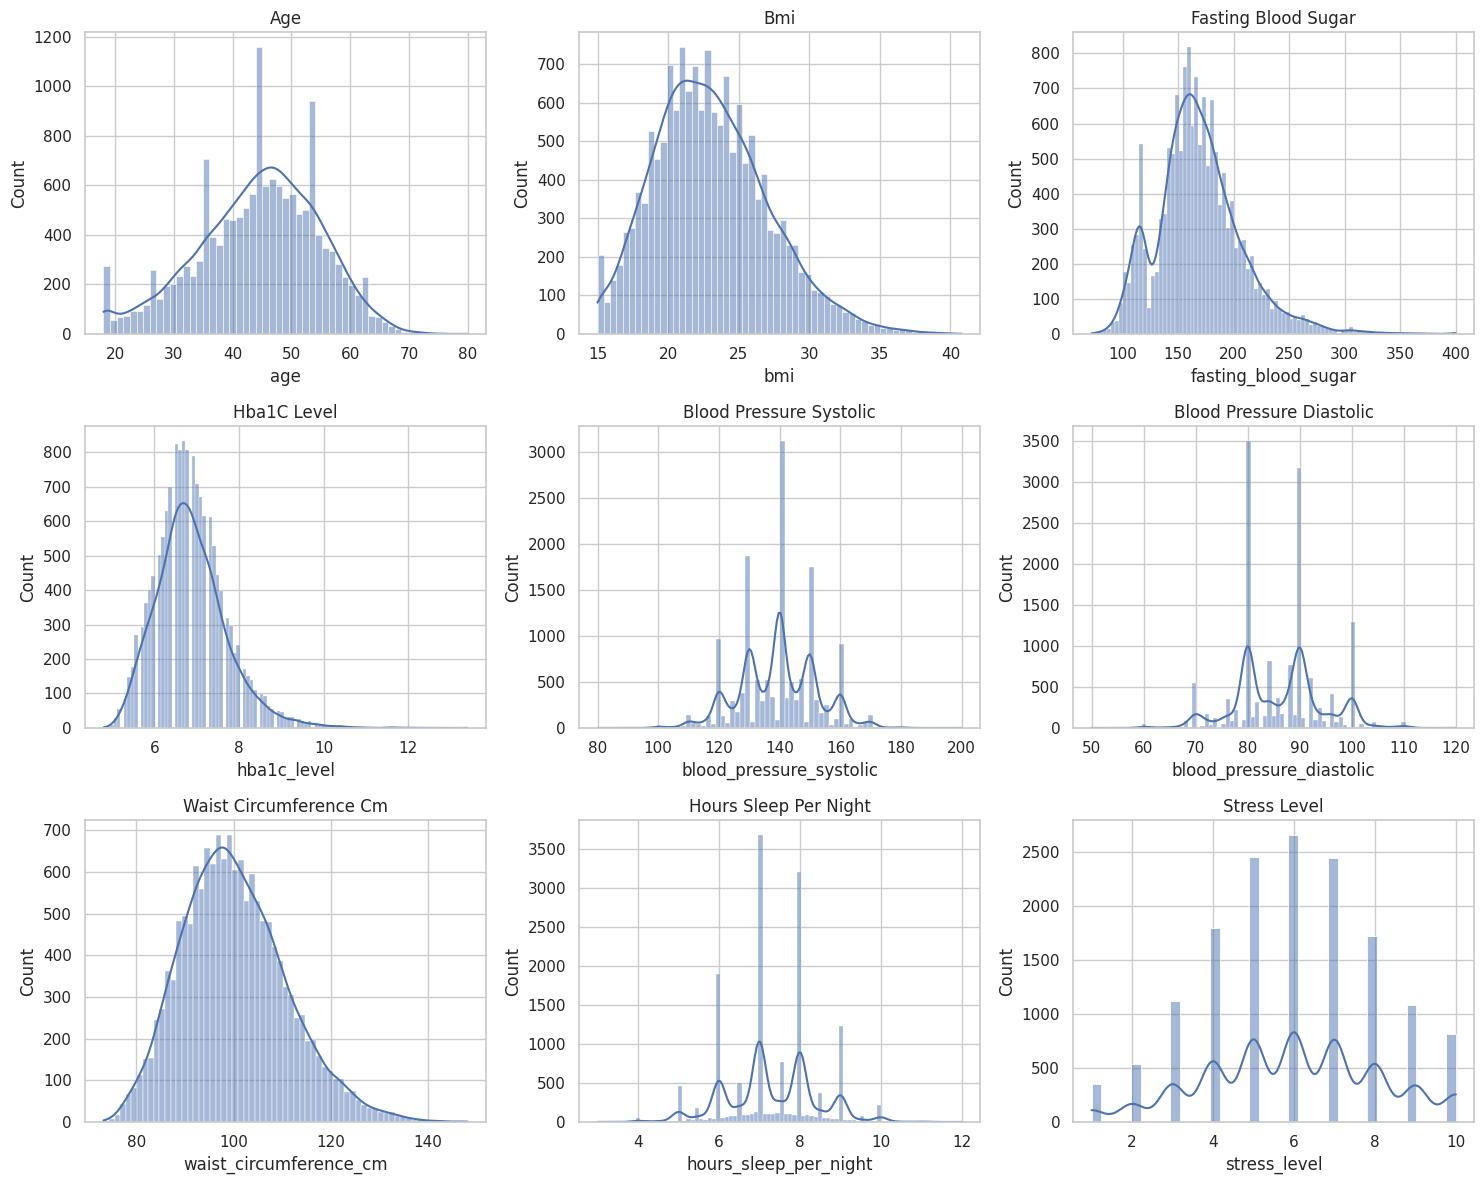

In [10]:
numeric_cols = ["age", "bmi", "fasting_blood_sugar", "hba1c_level",
                "blood_pressure_systolic", "blood_pressure_diastolic",
                "waist_circumference_cm", "hours_sleep_per_night", "stress_level"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col.replace("_", " ").title())
plt.tight_layout()
plt.show()

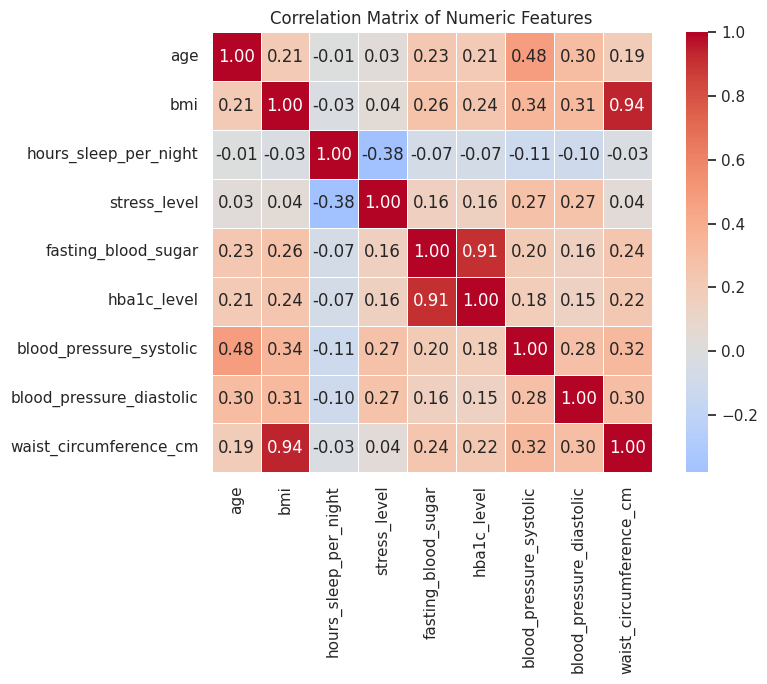

In [11]:
num_for_corr = df.select_dtypes(include=[np.number]).drop(columns=["patient_id"])
corr = num_for_corr.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

Shape of X_train: (12000, 42)
Shape of X_test: (3000, 42)
Shape of y_train: (12000,)
Shape of y_test: (3000,)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression Model Performance:
Accuracy: 0.7720

Classification Report:
              precision    recall  f1-score   support

        High       0.75      0.79      0.77       450
         Low       0.81      0.95      0.87      1800
    Moderate       0.62      0.34      0.44       750

    accuracy                           0.77      3000
   macro avg       0.73      0.69      0.69      3000
weighted avg       0.75      0.77      0.75      3000


Confusion Matrix:


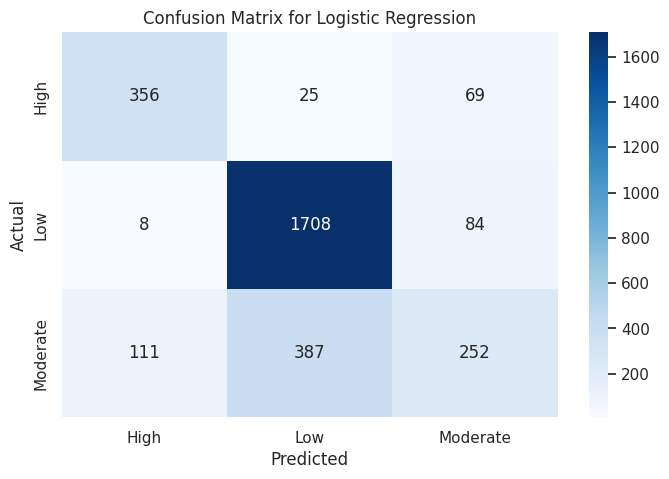

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Prepare data for logistic regression
# Drop patient_id as it's not a feature
df_model = df.drop("patient_id", axis=1).copy()

# Encode categorical features
# Use LabelEncoder for the target variable 'diabetes_risk'
le = LabelEncoder()
df_model["diabetes_risk_encoded"] = le.fit_transform(df_model["diabetes_risk"])
y = df_model["diabetes_risk_encoded"]

# One-hot encode other categorical features
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('diabetes_risk') # Exclude the original target column

df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Drop the original 'diabetes_risk' column as we have the encoded one
df_model = df_model.drop("diabetes_risk", axis=1)

# Define features (X) by dropping the target and its encoded version
X = df_model.drop("diabetes_risk_encoded", axis=1)

# Scale numerical features (optional but good practice for logistic regression)
scaler = StandardScaler()
numeric_cols_for_scaling = X.select_dtypes(include=[np.number]).columns.tolist()
X[numeric_cols_for_scaling] = scaler.fit_transform(X[numeric_cols_for_scaling])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Train a Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', multi_class='ovr') # 'liblinear' for small datasets, 'ovr' for multi-class
log_reg_model.fit(X_train, y_train)

# Make predictions
y_pred = log_reg_model.predict(X_test)

# Evaluate the model
print("\nLogistic Regression Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [13]:
from sklearn.model_selection import cross_val_score

# Re-initialize the model for cross-validation on the full dataset
cv_log_reg_model = LogisticRegression(random_state=42, solver='liblinear', multi_class='ovr')

# Perform 5-fold cross-validation
cv_scores = cross_val_score(cv_log_reg_model, X, y, cv=5, scoring='accuracy')

print("\nCross-validation Accuracy Scores:")
print(cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores.std():.4f}")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre


Cross-validation Accuracy Scores:
[0.77       0.77733333 0.77933333 0.77333333 0.77866667]
Mean CV Accuracy: 0.7757
Standard Deviation of CV Accuracy: 0.0035
